# Parametric Studies - MyBESS Voltage Event

In [1]:
include("../FullWorkflow/scripts/dictionaries.jl")
include("../FullWorkflow/scripts/helpers.jl")

using .FullWorkflowHelpers
using OMJulia, CSV, DataFrames

## User Configuration

In [2]:
# Initialized model used as the base case for the study.
BASE_MODEL = "MyBESS_initialized"
BASE_MODEL_FILE_PATH = abspath("../FullWorkflow/outputs/MyBESS_initialized.mo")

# Path to the Dynawo package.mo file.
DYNAWO_PKG_PATH = "/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo"

# Path to the Modelica package.mo file.
MODELICA_PKG_PATH = "/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo"

# Parameter sweep: voltage value during the voltage event.
SWEEP_COMPONENT = "infiniteBus"
SWEEP_PARAMETER = "UEvtPu"
VOLTAGE_JUMP_VALUES = [0.55, 0.65, 0.75, 0.85]

# Variable saved and plotted for each sweep case.
PLOT_VARIABLE = "BESS.terminal.V.re";


In [3]:
# Internal paths derived from the user configuration above.
OUTPUT_DIR = abspath("outputs")
PARAMETRIC_OUTPUT_DIR = joinpath(OUTPUT_DIR, "voltage_event_runs")

isfile(BASE_MODEL_FILE_PATH) || error("Initialized model file not found: $BASE_MODEL_FILE_PATH")
isfile(DYNAWO_PKG_PATH) || error("Dynawo package not found: $DYNAWO_PKG_PATH")
isfile(MODELICA_PKG_PATH) || error("Modelica package not found: $MODELICA_PKG_PATH")
# Start each sweep with a clean case-specific output directory.
rm(PARAMETRIC_OUTPUT_DIR; recursive = true, force = true)
mkpath(PARAMETRIC_OUTPUT_DIR)

println("Configuration checked successfully.")


Configuration checked successfully.


## Load the Initialized Model

In [4]:
StudyOMC = OMJulia.OMCSession()
omc_call(StudyOMC, "loadModel(Complex)")
omc_call(StudyOMC, "loadModel(ModelicaServices)")
omc_call(StudyOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
omc_call(StudyOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
omc_call(StudyOMC, "loadFile(\"$BASE_MODEL_FILE_PATH\")")

omc_call(StudyOMC, "checkModel($BASE_MODEL)", parsed = false)
println("Initialized base model checked successfully.")


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.VAr9A3N3Sz"


Initialized base model checked successfully.


## Sweep Helper Functions

In [5]:
function case_label(value)
    return replace(replace(string(value), "." => "p"), "-" => "m")
end

function _code_modification_from_assignments(assignments::Vector{String})
    return "\$Code((" * join(assignments, ", ") * "))"
end

function update_component_parameter!(omc, model::String, component::String, parameter::String, value)
    components = get_all_components(omc, model)
    haskey(components, component) || error("Component $component not found in $model")

    info = components[component]
    component_class = info["class"]::String
    modifiers = Dict{String, String}(info["modifiers"])
    call_modifiers = Dict{String, String}(info["call_modifiers"])

    modifiers[parameter] = string(value)

    assignments = String[]
    for (field, field_value) in sort(collect(modifiers))
        push!(assignments, "$field = $field_value")
    end
    for (field, field_value) in sort(collect(call_modifiers))
        push!(assignments, "$field($field_value)")
    end

    mod_str = _code_modification_from_assignments(assignments)
    omc_call(
        omc,
        "updateComponent($component, $component_class, $model, modification = $mod_str)",
        parsed = false,
    )
end;


## Run the Parameter Sweep

In [6]:
sweep_results = DataFrame[]

for value in VOLTAGE_JUMP_VALUES
    label = case_label(value)
    parameter_name = replace(SWEEP_PARAMETER, "." => "_")
    case_model = BASE_MODEL * "_" * parameter_name * "_" * label
    result_prefix = case_model

    sendExpression(StudyOMC, "deleteClass($case_model)")
    omc_call(StudyOMC, "copyClass($BASE_MODEL, \"$case_model\")")
    update_component_parameter!(StudyOMC, case_model, SWEEP_COMPONENT, SWEEP_PARAMETER, value)

    ModelicaSystem(StudyOMC, nothing, case_model, [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
    omc_call(StudyOMC, "checkModel($case_model)", parsed = false)

    simflags = simulation_flags_without_log_stats(StudyOMC, case_model)
    omc_call(
        StudyOMC,
        "simulate($case_model, outputFormat=\"csv\", fileNamePrefix=\"$result_prefix\", simflags=\"$simflags\")",
        parsed = false,
    )

    raw_resultfile = joinpath(getWorkDirectory(StudyOMC), result_prefix * "_res.csv")
    selected_resultfile = joinpath(PARAMETRIC_OUTPUT_DIR, result_prefix * "_selected.csv")

    df = DataFrame(CSV.File(raw_resultfile; select = ["time", PLOT_VARIABLE]))
    df[!, :case] .= label
    df[!, :UEvtPu] .= value

    CSV.write(selected_resultfile, df)
    push!(sweep_results, df)

    println("Finished case $label with $SWEEP_COMPONENT.$SWEEP_PARAMETER = $value")
end

sweep_df = vcat(sweep_results...)

println("Stored selected result files in: ", PARAMETRIC_OUTPUT_DIR)


Finished case 0p55 with infiniteBus.UEvtPu = 0.55
Finished case 0p65 with infiniteBus.UEvtPu = 0.65
Finished case 0p75 with infiniteBus.UEvtPu = 0.75
Finished case 0p85 with infiniteBus.UEvtPu = 0.85
Stored selected result files in: /home/clarafercas/dynawo-notebooks/OpenModelica_only_users/ParametricStudies/outputs/voltage_event_runs


## Compare Sweep Results

WebIO._IJuliaInit()

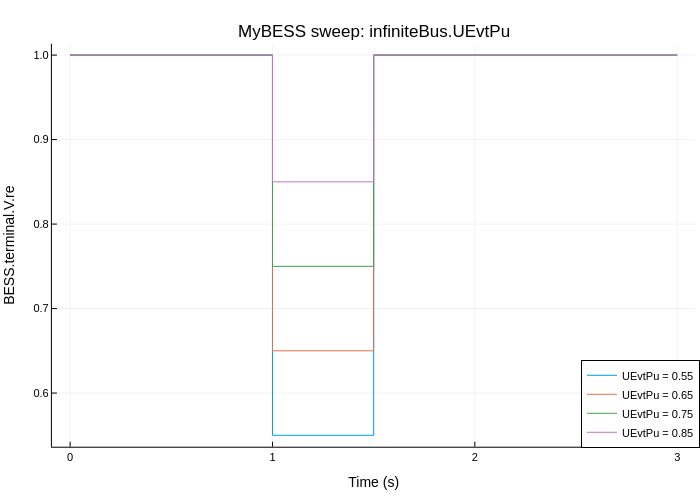

In [7]:
using Plots

plotlyjs()
p = plot(title = "MyBESS sweep: infiniteBus.UEvtPu", xlabel = "Time (s)", ylabel = PLOT_VARIABLE)

for case_group in groupby(sweep_df, :case)
    value = first(case_group.UEvtPu)
    plot!(p, case_group.time, case_group[!, PLOT_VARIABLE], label = "UEvtPu = $value")
end

plot!(p, legend = :bottomright, titlefontsize = 12, labelfontsize = 10)
